# Create age classifier

Train a **Random Forest**, **k-NN**, **HistGradientBoosting**, or **XGBoost** age-group classifier using [`heart_age_classifier.py`](heart_age_classifier.py).

1. Run **Imports & project root** once.
2. Edit **Shared settings** (data paths, features, split, imputer).
3. Optionally run **RF / k-NN data QC** (stacked random waveforms per class from the same train merge as the tree models).
4. Run **Random Forest**, **k-NN**, **HistGradientBoosting**, or **XGBoost** (separate cells) depending on which model you want.
5. Optionally run **Evaluation** (test CSVs cell) to load the saved pipeline, plot **test** prediction distributions, and tree-model feature importances from the saved (full-training) pipeline.
6. Run **Side-by-side confusion matrices** at the end to compare **all** row-normalized matrices in one figure (tree models you trained plus the ResNet-1D CNN if you ran that cell).

Keep this notebook in the same folder as `heart_age_classifier.py`, or adjust `NOTEBOOK_DIR` / `sys.path` in the first code cell.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

from cnn_age_classifier import (
    build_two_channel_resnet1d,
    extract_pulse_pressure_tabular,
    impute_waveform_gaps,
    load_two_channel_resnet_checkpoint,
    load_two_channel_waveforms,
    minmax_normalize_per_subject,
    preprocess_waveforms_phase1,
    save_two_channel_resnet_checkpoint,
    zscore_normalize_per_subject,
)

from heart_age_classifier import (
    ROLL_WINDOW_DEFAULT,
    TraceBlockLinearImputer,
    build_hgb_pipeline,
    build_knn_pipeline,
    build_model,
    build_xgb_pipeline,
    load_fitted_pipeline,
    load_param_grids_from_json,
    load_test_pair,
    load_train_pair,
    main,
    plot_confusion_matrices_row_panels,
    plot_train_pair_model_inputs_by_class_stacked,
    plot_train_pair_waveforms_by_class_stacked,
    plot_validation_normalized_confusion_matrices,
    visualize_predictions_on_test,
    xgb_available,
    _path_with_val_accuracy,
)

# Keep notebook imports centralized in this cell so the rest of the notebook
# focuses on configuration and execution.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

_root = NOTEBOOK_DIR.resolve()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

assert (_root / "heart_age_classifier.py").is_file(), (
    f"Expected heart_age_classifier.py in {_root} (got cwd={Path.cwd()})"
)

# PyTorch (CPU / Apple Silicon MPS)
try:
    import torch
except ImportError as e:
    raise ImportError("PyTorch is required for the CNN model. Install with: pip install torch") from e

# Prefer MPS on Apple Silicon, fall back to CPU.
DEVICE = (
    torch.device("mps")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available()
    else torch.device("cpu")
)

## Shared settings

Paths, feature mode, validation split, imputer, and output JSON locations. Used by all training cells below.

In [2]:
# --- Data paths (None = defaults beside heart_age_classifier.py: datasets/train, datasets/test) ---
TRAIN_AORTA = None  # e.g. NOTEBOOK_DIR / "datasets/train/aortaP_train_data.csv"
TRAIN_BRACH = None
TEST_AORTA = None
TEST_BRACH = None

training_csvs = None if TRAIN_AORTA is None else (TRAIN_AORTA, TRAIN_BRACH)
test_csvs = None if TEST_AORTA is None else (TEST_AORTA, TEST_BRACH)

# --- Features ---
FEATURE_MODE = "waveform_plus"  # "engineered" | "waveform" | "waveform_plus"
ROLL_WINDOW = 5  # ARV/CV/slope window for engineered scalars and waveform_plus rolling traces (>= 2)
# Names must match heart_age_classifier.ENGINEERED_FEATURE_NAMES (includes aorta_raw, brach_raw).
# engineered mode: scalar summaries only (do not list aorta_raw/brach_raw).
# waveform_plus: one 336-sample trace per listed name; aorta_raw / brach_raw = full CSV rows.
# waveform mode: list is passed but ignored by main with a warning.
ENGINEERED_COLUMNS = [
    # "aorta_raw",
    # "brach_raw",
    "aorta_cheb",
    "brach_cheb",
    # "aorta_preproc",
    # "brach_preproc",
    # "aorta_preproc_cheb",
    # "brach_preproc_cheb",
    # "ppa_ratio",
    # "ppa_diff",
    # "ppa_ratio_cheb",
    # "ppa_diff_cheb",
    # "aorta_pp",
    # "brach_pp",
    # "aorta_arv_roll_mean",
    # "brach_arv_roll_mean",
    # "aorta_cv_roll_mean",
    # "brach_cv_roll_mean",
    # "aorta_slope_roll_mean",
    # "brach_slope_roll_mean",
]
ENGINEERED_COLUMNS_FOR_MAIN = ENGINEERED_COLUMNS

# --- Train/validation split & job control ---
VAL_SPLIT = 0.2
RANDOM_STATE = 43  # None -> random seed printed at runtime
# Passed to sklearn as n_jobs: -1 uses all CPU cores; 1 disables parallelism; a positive int caps worker count.
N_JOBS = -1

# --- Optional GridSearchCV (fits on train fold only; stratified k-fold; holdout metrics unchanged) ---
GRID_SEARCH = True  # True -> search clf__* grids from heart_age_classifier defaults or JSON below
GRID_SEARCH_CV = 3
GRID_SEARCH_SCORING = "f1_macro"  # e.g. "accuracy", "f1_weighted"
GRID_SEARCH_VERBOSE = 1  # 1+ shows GridSearchCV progress
GRID_PARAMS_JSON = None  # optional Path; JSON object with keys "rf", "knn", "hgb", "xgb" -> param grids

GRID_RF_PARAM_GRID = GRID_KNN_PARAM_GRID = GRID_HGB_PARAM_GRID = GRID_XGB_PARAM_GRID = None
if GRID_PARAMS_JSON is not None:
    _gpj = load_param_grids_from_json(GRID_PARAMS_JSON)
    GRID_RF_PARAM_GRID = _gpj.get("rf")
    GRID_KNN_PARAM_GRID = _gpj.get("knn")
    GRID_HGB_PARAM_GRID = _gpj.get("hgb")
    GRID_XGB_PARAM_GRID = _gpj.get("xgb")

# When grid search runs, append discovered hyperparameters to the joblib stem (after _acc... if enabled).
EMBED_GRID_PARAMS_IN_SAVE_PATH = True

# --- Missing values (passed to pipeline imputer) ---
# Trace columns ``{name}_t_*``: linear along time per subject (:class:`TraceBlockLinearImputer`); other columns: median from the train fold.
IMPUTER_STRATEGY = "linear"
NAN_IMPUTER_CLS = TraceBlockLinearImputer
NAN_IMPUTER_KWARGS = {}

# --- Prediction JSON (written if default test CSVs exist) ---
OUT_JSON_RF = NOTEBOOK_DIR / "predictions.json"
OUT_JSON_KNN = NOTEBOOK_DIR / "predictions_knn.json"
OUT_JSON_HGB = NOTEBOOK_DIR / "predictions_hgb.json"
OUT_JSON_XGB = NOTEBOOK_DIR / "predictions_xgb.json"

### RF / k-NN data QC: **model input** traces

Six stacked panels (shared sample index): one **random** subject per `target` class. Curves are exactly the **`waveform_plus`** traces built by `extract_waveform_plus` with your **`ENGINEERED_COLUMNS_FOR_MAIN`** (e.g. `aorta_preproc_cheb`, `brach_preproc_cheb`) — the same columns as `load_train_pair` / RF / k-NN. CNN phase-1 kwargs default below; set **`CNN_MAX_GAP_SAMPLES`** etc. in the ResNet hyperparameters cell **before** this cell if you want them to match training, or duplicate those values here.

Optional: **`plot_train_pair_waveforms_by_class_stacked`** in `heart_age_classifier` plots raw CSV + Chebyshev overlay (data visualizer style), not the engineered model matrix.


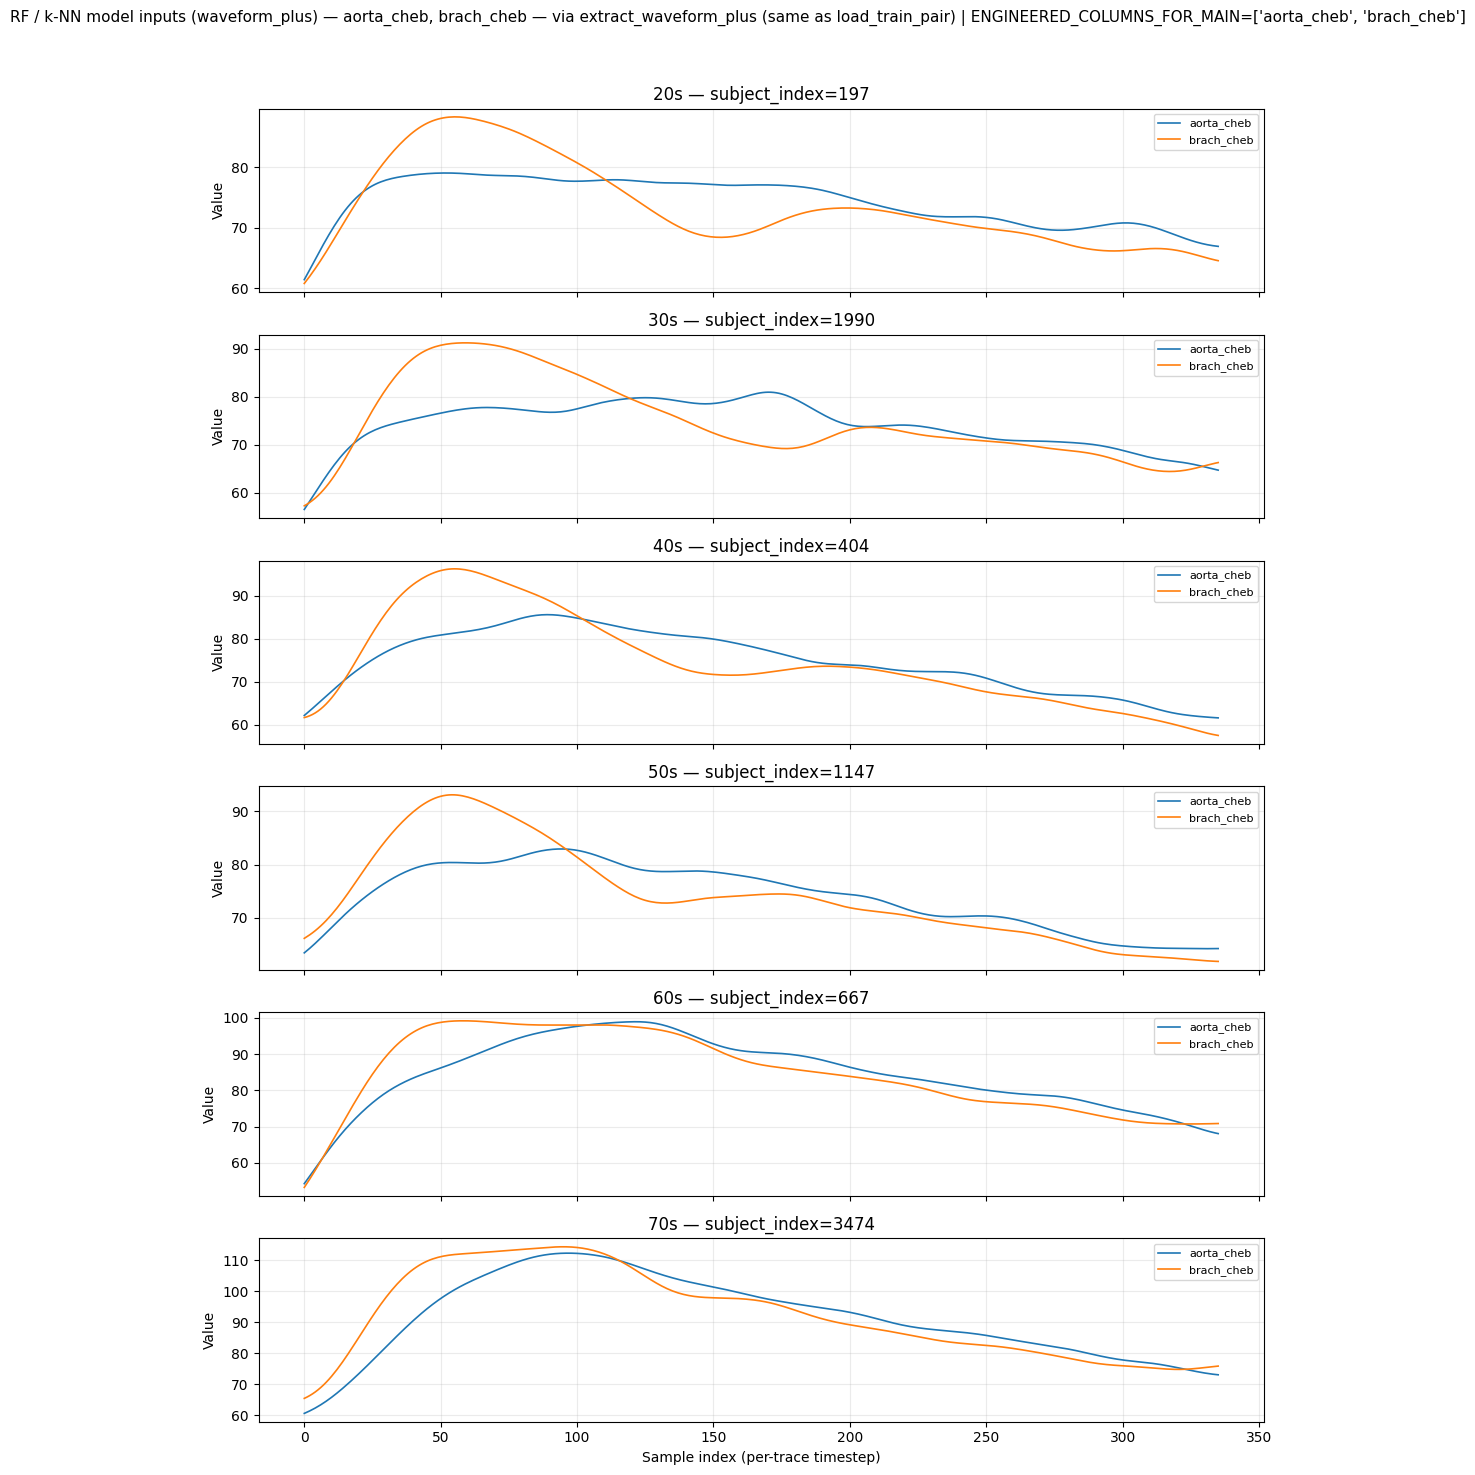

In [3]:
_root = NOTEBOOK_DIR.resolve()
if training_csvs is None:
    _plot_train_aorta = _root / "datasets/train/aortaP_train_data.csv"
    _plot_train_brach = _root / "datasets/train/brachP_train_data.csv"
else:
    _plot_train_aorta, _plot_train_brach = Path(training_csvs[0]), Path(training_csvs[1])

# Match CNN / waveform_plus *_preproc* traces (defaults align with typical ResNet cell).
_wf_cnn_gap = globals().get("CNN_MAX_GAP_SAMPLES", None)
_wf_cnn_gap_ms = globals().get("CNN_MAX_GAP_MS", None)
_wf_cnn_fs = globals().get("CNN_PHASE1_FS", 500.0)
_wf_cnn_z = globals().get("CNN_PHASE1_ZSCORE", "aorta_reference")

if not _plot_train_aorta.is_file() or not _plot_train_brach.is_file():
    print(f"Train CSVs not found for waveform QC: {_plot_train_aorta}, {_plot_train_brach}")
else:
    plot_train_pair_model_inputs_by_class_stacked(
        _plot_train_aorta,
        _plot_train_brach,
        feature_mode=FEATURE_MODE,
        roll_window=ROLL_WINDOW,
        engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
        waveform_plus_cnn_max_gap_samples=_wf_cnn_gap,
        waveform_plus_cnn_max_gap_ms=_wf_cnn_gap_ms,
        waveform_plus_cnn_sample_rate_hz=_wf_cnn_fs,
        waveform_plus_cnn_zscore_mode=_wf_cnn_z,
        title_suffix=f"| ENGINEERED_COLUMNS_FOR_MAIN={ENGINEERED_COLUMNS_FOR_MAIN!r}",
    )


## ResNet-1D (two-channel raw waveforms)

Build and train a ResNet‑1D on the **two raw waveforms** (`aorta_t_*` + `brach_t_*`) stacked into a **2‑channel** input per subject.

- **Input per subject**: `(336, 2)`
- **Cross-channel learning ("transit time calculators")**: early pointwise (1×1) convolution mixes the aorta + brach channels so temporal kernels can learn phase shifts / delays.
- **Digital-filter front-end**: early temporal kernels are small (7 then 5 samples).
- **Deep layers ("reflection analysts")**: later residual blocks use striding + dilation to widen receptive fields and capture macroscopic waveform shape.
- **Preprocess / normalization**: default **phase-1**—gap threshold, **linear** gap imputation (interpolate between adjacent finite samples on that channel), raw **pulse-pressure** scalars (max−min per channel) for the head, then **z-score** using **aortic μ,σ on both channels** (`CNN_PHASE1_ZSCORE`) or independent per-channel. Legacy: `CNN_PREPROCESS = "linear"` + `CNN_NORMALIZE`.
- **Global Average Pooling**: `GlobalAveragePooling1D()`
- **Dense output**: 6‑class **softmax** (multi-class), *or* 5‑threshold **ordinal** head (≥30s…≥70s), *or* **dual**: softmax + auxiliary **decade-index regression** (SmoothL1 on 0…5) via `CNN_OBJECTIVE = "dual"`
- **Training / evaluation**: early stopping on `CNN_EARLY_STOP_METRIC` with **`CNN_EARLY_STOP_PATIENCE`** and **`CNN_EARLY_STOP_MIN_DELTA`**; optional **`SAVE_MODEL_CNN`** / **`EMBED_CNN_VAL_ACCURACY_IN_SAVE_PATH`** (same `_acc{tenths}_` naming as tree **joblib** saves); **inference** summaries use **QWK**; optional **stratified K‑fold** (`CNN_CV_MODE = "skfold"`) with **OOF** confusion matrix; optional **temperature scaling** (`CNN_TEMPERATURE_CALIBRATE`) for multiclass/dual.


In [4]:
# # --- Hyperparameters ---
# CNN_VAL_SPLIT = 0.2
# CNN_RANDOM_STATE = 42
# CNN_EPOCHS = 100
# CNN_BATCH_SIZE = 64
# CNN_LEARNING_RATE = 1e-3
# CNN_WEIGHT_DECAY = 1e-2  # AdamW decoupled weight decay; use 0 to disable

# # Objective: "multiclass" (6-way softmax), "ordinal" (5 threshold questions), or
# # "dual" (6-way softmax + auxiliary decade-index regression, SmoothL1 on 0..5).
# CNN_OBJECTIVE = "ordinal"

# # Weight on regression loss when CNN_OBJECTIVE == "dual" (CE + λ * SmoothL1).
# CNN_REG_LOSS_WEIGHT = 0.5

# # Phase-1 load (default): no gap-based drops unless CNN_MAX_GAP_SAMPLES or CNN_MAX_GAP_MS is set;
# # remaining gaps filled with linear interpolation; then per-subject z-score per channel (see ``preprocess_waveforms_phase1``).
# CNN_PREPROCESS = "phase1"  # "none" | "linear" | "phase1"
# # Extra scaling after load (use only if CNN_PREPROCESS is "linear" or "none"; phase-1 already z-scores).
# CNN_NORMALIZE = "none"  # "minmax" | "zscore" | "none"

# # Gap threshold: samples or ms.
# CNN_MAX_GAP_SAMPLES = None
# CNN_MAX_GAP_MS = None  # e.g. 40.0 → max gap in ms at CNN_PHASE1_FS (overrides sample count)
# CNN_PHASE1_FS = 500.0

# # ``aorta_reference``: aortic μ,σ on both channels; ``independent``: per-channel z-score.
# CNN_PHASE1_ZSCORE = "aorta_reference"  # "aorta_reference" | "independent"

# # "holdout": single stratified train/val split (CNN_VAL_SPLIT).
# # "skfold": stratified K-fold; metrics mean±std + OOF confusion matrix.
# CNN_CV_MODE = "skfold"  # "holdout" | "skfold"
# CNN_CV_SPLITS = 5

# # Early stopping selects the checkpoint that optimizes this validation metric:
# # "loss" (minimize), "macro_f1" (maximize), "balanced_accuracy" (maximize),
# # "qwk" (maximize quadratic weighted kappa on validation class predictions).
# CNN_EARLY_STOP_METRIC = "macro_f1"

# # Stricter early stopping: more epochs without a "real" improvement before quit, and
# # improvements must exceed min_delta (maximize: new > best + min_delta; loss: new < best - min_delta).
# CNN_EARLY_STOP_PATIENCE = 15
# CNN_EARLY_STOP_MIN_DELTA = 5e-4

# # Post-hoc temperature scaling on 6-way logits (multiclass / dual only).
# CNN_TEMPERATURE_CALIBRATE = True
# CNN_TEMPERATURE_STEPS = 100
# CNN_TEMPERATURE_LR = 0.05

# # Save trained CNN (PyTorch ``.pt``), same _acc{tenths}_ idea as RF/k-NN ``.joblib`` names.
# SAVE_MODEL_CNN = NOTEBOOK_DIR / "models" / "heart_age_cnn.pt"
# # SAVE_MODEL_CNN = None  # uncomment to skip saving
# EMBED_CNN_VAL_ACCURACY_IN_SAVE_PATH = True
# # With CNN_CV_MODE == "skfold", the saved weights are the single fold with highest val QWK (not an ensemble).

### Train Model

In [5]:
# # --- Load + preprocess ---
# X, y, pp_tab = load_two_channel_waveforms(
#     train_aorta_csv=TRAIN_AORTA,
#     train_brach_csv=TRAIN_BRACH,
#     base_dir=NOTEBOOK_DIR,
#     preprocess=CNN_PREPROCESS,
#     max_gap_samples=CNN_MAX_GAP_SAMPLES,
#     max_gap_ms=CNN_MAX_GAP_MS,
#     sample_rate_hz=CNN_PHASE1_FS,
#     zscore_mode=CNN_PHASE1_ZSCORE,
# )
# if pp_tab is None:
#     pp_tab = np.zeros((X.shape[0], 2), dtype=np.float32)
# if CNN_PREPROCESS == "phase1":
#     pass
# elif CNN_NORMALIZE == "minmax":
#     X = minmax_normalize_per_subject(X)
# elif CNN_NORMALIZE == "zscore":
#     X = zscore_normalize_per_subject(X)
# elif CNN_NORMALIZE == "none":
#     pass
# else:
#     raise ValueError(
#         f"CNN_NORMALIZE must be 'minmax', 'zscore', or 'none'; got {CNN_NORMALIZE!r}"
#     )

# # y is one-hot (n, 6)
# y_int = np.argmax(y, axis=1)


# def quadratic_weighted_kappa(y_true: np.ndarray, y_pred: np.ndarray) -> float:
#     """Quadratic weighted kappa for ordinal / decade class indices (0..K-1)."""
#     y_true = np.asarray(y_true, dtype=np.int64).reshape(-1)
#     y_pred = np.asarray(y_pred, dtype=np.int64).reshape(-1)
#     if y_true.size == 0:
#         return 0.0
#     k = cohen_kappa_score(y_true, y_pred, weights="quadratic")
#     if k is None or (isinstance(k, float) and np.isnan(k)):
#         return 0.0
#     return float(k)


# def to_ordinal_targets(y_class: np.ndarray, n_classes: int = 6) -> np.ndarray:
#     """Convert class 0..(n_classes-1) into ordinal threshold targets of shape (N, n_classes-1).

#     For 6 decades, thresholds correspond to:
#       >=30s, >=40s, >=50s, >=60s, >=70s
#     Example: class=3 (50s) -> [1, 1, 1, 0, 0]
#     """
#     y_class = np.asarray(y_class, dtype=np.int64).reshape(-1)
#     K = int(n_classes)
#     if np.any((y_class < 0) | (y_class >= K)):
#         bad = y_class[(y_class < 0) | (y_class >= K)]
#         raise ValueError(f"class outside 0..{K-1}: {bad[:10]}")
#     thr = np.arange(1, K, dtype=np.int64)[None, :]
#     return (y_class[:, None] >= thr).astype(np.float32)


# def _class_preds_from_logits(logits: torch.Tensor, objective: str) -> np.ndarray:
#     """Map network outputs to hard class indices in 0..n_classes-1 for metrics (e.g. QWK).

#     - ``multiclass`` / ``dual``: ``argmax(softmax(logits), dim=1)``.
#     - ``ordinal``: five threshold logits → ``sigmoid`` then count how many are ≥ 0.5
#       (same decoding as training targets from ``to_ordinal_targets``), yielding integers 0..5.
#     """
#     if objective in ("multiclass", "dual"):
#         return (
#             torch.softmax(logits, dim=1).argmax(dim=1).detach().cpu().numpy().astype(np.int64)
#         )
#     thr = torch.sigmoid(logits).detach().cpu().numpy()
#     return (thr >= 0.5).sum(axis=1).astype(np.int64)


# def _fit_temperature(
#     logits: torch.Tensor,
#     labels: torch.Tensor,
#     *,
#     steps: int,
#     lr: float,
# ) -> float:
#     """Scalar T>0: minimize CE( softmax(logits/T), labels ) on a held-out set."""
#     logits = logits.detach().float()
#     labels = labels.detach().long()
#     log_t = torch.zeros(1, device=logits.device, requires_grad=True)
#     opt = torch.optim.Adam([log_t], lr=lr)
#     ce = torch.nn.CrossEntropyLoss()
#     for _ in range(int(steps)):
#         opt.zero_grad(set_to_none=True)
#         t = torch.exp(log_t).clamp(min=0.05, max=50.0)
#         loss = ce(logits / t, labels)
#         loss.backward()
#         opt.step()
#     return float(torch.exp(log_t).detach().clamp(min=0.05, max=50.0).cpu().item())


# def _val_forward_logits(
#     model: torch.nn.Module,
#     X_val_t: torch.Tensor,
#     objective: str,
#     pp_val_t: torch.Tensor,
# ) -> torch.Tensor:
#     if objective == "dual":
#         v_logits, _ = model(X_val_t, pp_val_t)
#         return v_logits
#     return model(X_val_t, pp_val_t)


# def _early_stop_improved(
#     metric_name: str,
#     current_loss: float,
#     current_f1: float,
#     current_bacc: float,
#     current_qwk: float,
#     best: dict,
#     *,
#     min_delta: float,
# ) -> bool:
#     md = float(min_delta)
#     if metric_name == "loss":
#         return float(current_loss) < float(best["value"]) - md
#     if metric_name == "macro_f1":
#         return float(current_f1) > float(best["value"]) + md
#     if metric_name == "balanced_accuracy":
#         return float(current_bacc) > float(best["value"]) + md
#     if metric_name == "qwk":
#         return float(current_qwk) > float(best["value"]) + md
#     raise ValueError(
#         f"CNN_EARLY_STOP_METRIC must be 'loss', 'macro_f1', 'balanced_accuracy', or 'qwk'; got {metric_name!r}"
#     )


# def _early_stop_init(
#     metric_name: str,
#     current_loss: float,
#     current_f1: float,
#     current_bacc: float,
#     current_qwk: float,
# ) -> dict:
#     if metric_name == "loss":
#         return {"name": metric_name, "value": float(current_loss)}
#     if metric_name == "macro_f1":
#         return {"name": metric_name, "value": float(current_f1)}
#     if metric_name == "balanced_accuracy":
#         return {"name": metric_name, "value": float(current_bacc)}
#     if metric_name == "qwk":
#         return {"name": metric_name, "value": float(current_qwk)}
#     raise ValueError(
#         f"CNN_EARLY_STOP_METRIC must be 'loss', 'macro_f1', 'balanced_accuracy', or 'qwk'; got {metric_name!r}"
#     )


# def train_one_split(
#     X_train: np.ndarray,
#     y_train: np.ndarray,
#     y_train_int: np.ndarray,
#     X_val: np.ndarray,
#     y_val_int: np.ndarray,
#     pp_train: np.ndarray,
#     pp_val: np.ndarray,
#     *,
#     fold_tag: str = "",
# ) -> dict:
#     if CNN_OBJECTIVE == "multiclass":
#         model = build_two_channel_resnet1d(n_classes=6).to(DEVICE)
#     elif CNN_OBJECTIVE == "ordinal":
#         model = build_two_channel_resnet1d(n_classes=5).to(DEVICE)
#     elif CNN_OBJECTIVE == "dual":
#         model = build_two_channel_resnet1d(n_classes=6, auxiliary_regression=True).to(DEVICE)
#     else:
#         raise ValueError(
#             f"CNN_OBJECTIVE must be 'multiclass', 'ordinal', or 'dual'; got {CNN_OBJECTIVE!r}"
#         )

#     X_train_t = torch.from_numpy(X_train).permute(0, 2, 1).to(torch.float32).to(DEVICE)
#     X_val_t = torch.from_numpy(X_val).permute(0, 2, 1).to(torch.float32).to(DEVICE)
#     pp_train_t = torch.from_numpy(np.asarray(pp_train, dtype=np.float32)).to(DEVICE)
#     pp_val_t = torch.from_numpy(np.asarray(pp_val, dtype=np.float32)).to(DEVICE)

#     if CNN_OBJECTIVE == "multiclass":
#         y_train_t = torch.from_numpy(y_train_int).to(torch.long).to(DEVICE)
#         y_val_t = torch.from_numpy(y_val_int).to(torch.long).to(DEVICE)
#     elif CNN_OBJECTIVE == "dual":
#         y_train_t = torch.from_numpy(y_train_int).to(torch.long).to(DEVICE)
#         y_val_t = torch.from_numpy(y_val_int).to(torch.long).to(DEVICE)
#         y_train_reg_t = torch.from_numpy(y_train_int.astype(np.float32)).to(DEVICE)
#         y_val_reg_t = torch.from_numpy(y_val_int.astype(np.float32)).to(DEVICE)
#     else:
#         y_train_t = torch.from_numpy(to_ordinal_targets(y_train_int, n_classes=6)).to(torch.float32).to(DEVICE)
#         y_val_t = torch.from_numpy(to_ordinal_targets(y_val_int, n_classes=6)).to(torch.float32).to(DEVICE)

#     if CNN_OBJECTIVE == "dual":
#         train_ds = torch.utils.data.TensorDataset(
#             X_train_t, y_train_t, y_train_reg_t, pp_train_t
#         )
#     else:
#         train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t, pp_train_t)
#     train_loader = torch.utils.data.DataLoader(train_ds, batch_size=CNN_BATCH_SIZE, shuffle=True)

#     if CNN_OBJECTIVE == "multiclass" or CNN_OBJECTIVE == "dual":
#         criterion = torch.nn.CrossEntropyLoss()
#     else:
#         criterion = torch.nn.BCEWithLogitsLoss()
#     criterion_reg = torch.nn.SmoothL1Loss() if CNN_OBJECTIVE == "dual" else None
#     optim = torch.optim.AdamW(
#         model.parameters(), lr=CNN_LEARNING_RATE, weight_decay=CNN_WEIGHT_DECAY
#     )
#     sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optim, mode="min", factor=0.5, patience=4, min_lr=1e-6
#     )

#     pat = 0
#     best_track = None
#     best_state = None

#     for epoch in range(1, CNN_EPOCHS + 1):
#         model.train()
#         tr_loss = 0.0
#         n = 0
#         if CNN_OBJECTIVE == "dual":
#             for xb, yb_cls, yb_reg, ppb in train_loader:
#                 optim.zero_grad(set_to_none=True)
#                 logits, reg_pred = model(xb, ppb)
#                 loss = criterion(logits, yb_cls) + CNN_REG_LOSS_WEIGHT * criterion_reg(
#                     reg_pred.squeeze(-1), yb_reg
#                 )
#                 loss.backward()
#                 optim.step()
#                 tr_loss += float(loss.item()) * xb.shape[0]
#                 n += xb.shape[0]
#         else:
#             for xb, yb, ppb in train_loader:
#                 optim.zero_grad(set_to_none=True)
#                 logits = model(xb, ppb)
#                 loss = criterion(logits, yb)
#                 loss.backward()
#                 optim.step()
#                 tr_loss += float(loss.item()) * xb.shape[0]
#                 n += xb.shape[0]

#         model.eval()
#         with torch.no_grad():
#             if CNN_OBJECTIVE == "dual":
#                 val_logits, val_reg = model(X_val_t, pp_val_t)
#                 val_loss = float(
#                     criterion(val_logits, y_val_t).item()
#                     + CNN_REG_LOSS_WEIGHT * criterion_reg(val_reg.squeeze(-1), y_val_reg_t).item()
#                 )
#             else:
#                 val_logits = model(X_val_t, pp_val_t)
#                 val_loss = float(criterion(val_logits, y_val_t).item())
#             val_pred_ep = _class_preds_from_logits(val_logits, CNN_OBJECTIVE)
#             vf1 = float(
#                 f1_score(y_val_int, val_pred_ep, average="macro", zero_division=0)
#             )
#             vbacc = float(balanced_accuracy_score(y_val_int, val_pred_ep))
#             vqwk = quadratic_weighted_kappa(y_val_int, val_pred_ep)

#         sched.step(val_loss)
#         tr_loss = tr_loss / max(1, n)

#         print(
#             f"{fold_tag}epoch={epoch:03d} train_loss={tr_loss:.4f} val_loss={val_loss:.4f} "
#             f"val_macro_f1={vf1:.4f} val_bal_acc={vbacc:.4f} val_qwk={vqwk:.4f}"
#         )

#         if best_track is None:
#             best_track = _early_stop_init(
#                 CNN_EARLY_STOP_METRIC, val_loss, vf1, vbacc, vqwk
#             )
#             best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
#         elif _early_stop_improved(
#             CNN_EARLY_STOP_METRIC,
#             val_loss,
#             vf1,
#             vbacc,
#             vqwk,
#             best_track,
#             min_delta=CNN_EARLY_STOP_MIN_DELTA,
#         ):
#             if CNN_EARLY_STOP_METRIC == "loss":
#                 best_track["value"] = float(val_loss)
#             elif CNN_EARLY_STOP_METRIC == "macro_f1":
#                 best_track["value"] = float(vf1)
#             elif CNN_EARLY_STOP_METRIC == "balanced_accuracy":
#                 best_track["value"] = float(vbacc)
#             else:
#                 best_track["value"] = float(vqwk)
#             pat = 0
#             best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
#         else:
#             pat += 1
#             if pat >= CNN_EARLY_STOP_PATIENCE:
#                 print(f"{fold_tag}Early stopping (metric={CNN_EARLY_STOP_METRIC})")
#                 break

#     model.load_state_dict(best_state)
#     model.eval()

#     temperature = None
#     with torch.no_grad():
#         val_logits = _val_forward_logits(model, X_val_t, CNN_OBJECTIVE, pp_val_t)

#     if CNN_TEMPERATURE_CALIBRATE and CNN_OBJECTIVE in ("multiclass", "dual"):
#         temperature = _fit_temperature(
#             val_logits,
#             y_val_t,
#             steps=CNN_TEMPERATURE_STEPS,
#             lr=CNN_TEMPERATURE_LR,
#         )
#         with torch.no_grad():
#             val_pred = (
#                 torch.softmax(val_logits / temperature, dim=1)
#                 .argmax(dim=1)
#                 .detach()
#                 .cpu()
#                 .numpy()
#                 .astype(np.int64)
#             )
#         print(f"{fold_tag}Temperature scaling: T={temperature:.4f} (fit on validation logits)")
#     else:
#         val_pred = _class_preds_from_logits(val_logits, CNN_OBJECTIVE)

#     reg_mae = None
#     if CNN_OBJECTIVE == "dual":
#         with torch.no_grad():
#             _, val_reg = model(X_val_t, pp_val_t)
#             reg_mae = float(
#                 np.mean(np.abs(val_reg.squeeze(-1).detach().cpu().numpy() - y_val_int))
#             )
#         print(f"{fold_tag}CNN auxiliary decade-reg MAE (holdout): {reg_mae:.4f}")

#     acc = float(accuracy_score(y_val_int, val_pred))
#     macro_f1 = float(f1_score(y_val_int, val_pred, average="macro", zero_division=0))
#     bal_acc = float(balanced_accuracy_score(y_val_int, val_pred))
#     qwk = quadratic_weighted_kappa(y_val_int, val_pred)

#     return {
#         "val_pred": val_pred,
#         "val_true": y_val_int,
#         "acc": acc,
#         "macro_f1": macro_f1,
#         "balanced_accuracy": bal_acc,
#         "qwk": qwk,
#         "temperature": temperature,
#         "reg_mae": reg_mae,
#         "model": model,
#     }


# if CNN_CV_MODE not in ("holdout", "skfold"):
#     raise ValueError(f"CNN_CV_MODE must be 'holdout' or 'skfold'; got {CNN_CV_MODE!r}")

# if CNN_CV_MODE == "holdout":
#     X_train, X_val, y_train, y_val, y_train_int, y_val_int, pp_train, pp_val = train_test_split(
#         X,
#         y,
#         y_int,
#         pp_tab,
#         test_size=CNN_VAL_SPLIT,
#         random_state=CNN_RANDOM_STATE,
#         stratify=y_int,
#     )
#     out = train_one_split(
#         X_train,
#         y_train,
#         y_train_int,
#         X_val,
#         y_val_int,
#         pp_train,
#         pp_val,
#         fold_tag="",
#     )
#     cnn_train_out = out
#     y_eval_true = out["val_true"]
#     y_eval_pred = out["val_pred"]
# else:
#     skf = StratifiedKFold(
#         n_splits=int(CNN_CV_SPLITS),
#         shuffle=True,
#         random_state=CNN_RANDOM_STATE,
#     )
#     oof_pred = np.zeros(len(y_int), dtype=np.int64)
#     fold_rows = []
#     for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X, y_int)):
#         tag = f"[fold {fold_idx + 1}/{CNN_CV_SPLITS}] "
#         res = train_one_split(
#             X[tr_idx],
#             y[tr_idx],
#             y_int[tr_idx],
#             X[va_idx],
#             y_int[va_idx],
#             pp_tab[tr_idx],
#             pp_tab[va_idx],
#             fold_tag=tag,
#         )
#         oof_pred[va_idx] = res["val_pred"]
#         fold_rows.append(res)
#         print(
#             f"{tag}fold val qwk={res['qwk']:.4f} acc={res['acc']:.4f} "
#             f"macro_f1={res['macro_f1']:.4f} bal_acc={res['balanced_accuracy']:.4f}"
#         )

#     accs = np.array([r["acc"] for r in fold_rows], dtype=np.float64)
#     f1s = np.array([r["macro_f1"] for r in fold_rows], dtype=np.float64)
#     bacs = np.array([r["balanced_accuracy"] for r in fold_rows], dtype=np.float64)
#     qwks = np.array([r["qwk"] for r in fold_rows], dtype=np.float64)
#     print(
#         f"CV mean±std qwk={qwks.mean():.4f}±{qwks.std():.4f} "
#         f"acc={accs.mean():.4f}±{accs.std():.4f} "
#         f"macro_f1={f1s.mean():.4f}±{f1s.std():.4f} "
#         f"bal_acc={bacs.mean():.4f}±{bacs.std():.4f}"
#     )
#     y_eval_true = y_int
#     y_eval_pred = oof_pred
#     cnn_train_out = max(fold_rows, key=lambda r: r["qwk"])

# qwk_eval = quadratic_weighted_kappa(y_eval_true, y_eval_pred)
# acc = float(accuracy_score(y_eval_true, y_eval_pred))
# print(f"CNN eval quadratic weighted kappa ({CNN_CV_MODE}): {qwk_eval:.4f}")
# print(f"CNN eval accuracy ({CNN_CV_MODE}, reference): {acc:.4f}")
# print(classification_report(y_eval_true, y_eval_pred, digits=4))

# SAVED_MODEL_CNN = None
# if SAVE_MODEL_CNN is not None:
#     _cnn_save = Path(SAVE_MODEL_CNN)
#     _cnn_save.parent.mkdir(parents=True, exist_ok=True)
#     _cnn_path = _cnn_save
#     if EMBED_CNN_VAL_ACCURACY_IN_SAVE_PATH:
#         _cnn_path = _path_with_val_accuracy(_cnn_save, acc)
#     SAVED_MODEL_CNN = save_two_channel_resnet_checkpoint(
#         _cnn_path,
#         cnn_train_out["model"],
#         objective=CNN_OBJECTIVE,
#         n_classes=5 if CNN_OBJECTIVE == "ordinal" else 6,
#         auxiliary_regression=CNN_OBJECTIVE == "dual",
#         tabular_pp_dim=2,
#         temperature=cnn_train_out["temperature"],
#     )
#     print(f"Saved CNN checkpoint: {SAVED_MODEL_CNN}")


In [6]:
# CNN confusion matrix is plotted in the final **Side-by-side confusion matrices** cell
# (together with tree models). Run that cell after the CNN training cell above.
pass

## Random Forest

Edit **Shared settings** for data paths, feature mode, validation split, and imputer. In this cell, adjust **Random Forest** hyperparameters and base save path; the file written includes holdout accuracy in the name as **tenths of a percent** (e.g. 98.63% → `heart_age_rf_acc986.joblib`). `SAVE_MODEL_RF` is updated to that path for the evaluation cell.

In [7]:
# visualize random waveform


In [8]:
# --- Random Forest only (paths, features, split, imputer, jobs: Shared settings cell) ---
N_ESTIMATORS = 300
MAX_DEPTH = None  # int or None (unlimited)
CLASS_WEIGHT = "balanced"  # "balanced" | "balanced_subsample" | None | dict

SAVE_MODEL_RF = NOTEBOOK_DIR / "models" / "heart_age_rf.joblib"
# SAVE_MODEL_RF = None  # uncomment to skip saving

_train_out = main(
    classifier="rf",
    training_csvs=training_csvs,
    test_csvs=test_csvs,
    out_json=OUT_JSON_RF,
    out_json_knn=OUT_JSON_KNN,
    save_model_rf=SAVE_MODEL_RF,
    save_model_knn=None,
    feature_mode=FEATURE_MODE,
    roll_window=ROLL_WINDOW,
    engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
    val_split=VAL_SPLIT,
    nan_imputer_cls=NAN_IMPUTER_CLS,
    nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    class_weight=CLASS_WEIGHT,
    knn_neighbors=7,
    knn_weights="distance",
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    embed_validation_accuracy_in_save_path=True,
    embed_grid_search_params_in_save_path=EMBED_GRID_PARAMS_IN_SAVE_PATH,
    grid_search=GRID_SEARCH,
    grid_search_cv=GRID_SEARCH_CV,
    grid_search_scoring=GRID_SEARCH_SCORING,
    grid_search_verbose=GRID_SEARCH_VERBOSE,
    rf_param_grid=GRID_RF_PARAM_GRID,
)
if _train_out.get("saved_model_rf"):
    SAVE_MODEL_RF = _train_out["saved_model_rf"]
LAST_TRAIN_RANDOM_STATE = _train_out["random_state_used"]
_train_out.get("val_accuracy_rf"), SAVE_MODEL_RF

Fitting 3 folds for each of 18 candidates, totalling 54 fits
=== Random Forest (features=waveform_plus) — GridSearchCV (scoring='f1_macro', cv=3) ===
Best mean CV score: 0.63885
=== Discovered hyperparameters (best grid point) — Random Forest (features=waveform_plus) ===
  clf__max_depth         =  20
  clf__min_samples_leaf  =  1
  clf__n_estimators      =  100
=== Random Forest (features=waveform_plus) — holdout (same stratified split as main; not used in CV) ===
              precision    recall  f1-score   support

           0      0.965     0.940     0.952       116
           1      0.888     0.880     0.884       117
           2      0.522     0.588     0.553       119
           3      0.398     0.353     0.374       116
           4      0.516     0.557     0.536       115
           5      0.773     0.726     0.749       117

    accuracy                          0.674       700
   macro avg      0.677     0.674     0.675       700
weighted avg      0.677     0.674     0.67

(0.6742857142857143,
 PosixPath('/Users/brycesmith/Documents/MaXentric/4359_STRETCH/Proposals/DARPA/DTC Data/models/heart_age_rf_acc674_hp_max_depth-20__min_samples_leaf-1__n_estimators-100.joblib'))

## k-Nearest Neighbors

Tune k-NN here, then run the cell. The saved file name includes holdout accuracy as tenths of a percent (e.g. 98.63% → `heart_age_knn_acc986.joblib`). `SAVE_MODEL_KNN` is updated for the evaluation cell.

In [9]:
# # --- k-NN ---
# KNN_NEIGHBORS = 3
# KNN_WEIGHTS = "distance"  # "uniform" | "distance"

# SAVE_MODEL_KNN = NOTEBOOK_DIR / "models" / "heart_age_knn.joblib"
# # SAVE_MODEL_KNN = None  # uncomment to skip saving

# _train_out = main(
#     classifier="knn",
#     training_csvs=training_csvs,
#     test_csvs=test_csvs,
#     out_json=OUT_JSON_RF,
#     out_json_knn=OUT_JSON_KNN,
#     save_model_rf=None,
#     save_model_knn=SAVE_MODEL_KNN,
#     feature_mode=FEATURE_MODE,
#     roll_window=ROLL_WINDOW,
#     engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
#     val_split=VAL_SPLIT,
#     nan_imputer_cls=NAN_IMPUTER_CLS,
#     nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
#     n_estimators=200,
#     max_depth=None,
#     class_weight="balanced_subsample",
#     knn_neighbors=KNN_NEIGHBORS,
#     knn_weights=KNN_WEIGHTS,
#     n_jobs=N_JOBS,
#     random_state=RANDOM_STATE,
#     embed_validation_accuracy_in_save_path=True,
#     embed_grid_search_params_in_save_path=EMBED_GRID_PARAMS_IN_SAVE_PATH,
#     grid_search=GRID_SEARCH,
#     grid_search_cv=GRID_SEARCH_CV,
#     grid_search_scoring=GRID_SEARCH_SCORING,
#     grid_search_verbose=GRID_SEARCH_VERBOSE,
#     knn_param_grid=GRID_KNN_PARAM_GRID,
# )
# if _train_out.get("saved_model_knn"):
#     SAVE_MODEL_KNN = _train_out["saved_model_knn"]
# LAST_TRAIN_RANDOM_STATE = _train_out["random_state_used"]
# _train_out.get("val_accuracy_knn"), SAVE_MODEL_KNN

## HistGradientBoosting

Edit **Shared settings** first. This cell trains scikit-learn `HistGradientBoostingClassifier` (histogram-based gradient boosting). Tune **learning rate**, **max_iter**, depth/leaf settings, and optional **class_weight** / **L2**. The saved filename can include holdout accuracy like the other models. `SAVE_MODEL_HGB` is updated for the evaluation cell.

In [10]:
# # --- HistGradientBoosting (paths, features, split, imputer, jobs: Shared settings) ---
# HGB_LEARNING_RATE = 0.08
# HGB_MAX_ITER = 200
# HGB_MAX_DEPTH = None  # int or None (None = no depth limit per sklearn)
# HGB_MAX_LEAF_NODES = 31
# HGB_L2 = 0.1
# HGB_CLASS_WEIGHT = "balanced"  # None | "balanced" | dict
# HGB_EARLY_STOPPING = "auto"  # "auto" | True | False

# SAVE_MODEL_HGB = NOTEBOOK_DIR / "models" / "heart_age_hgb.joblib"
# # SAVE_MODEL_HGB = None  # uncomment to skip saving

# _train_out = main(
#     classifier="hgb",
#     training_csvs=training_csvs,
#     test_csvs=test_csvs,
#     out_json=OUT_JSON_RF,
#     out_json_knn=OUT_JSON_KNN,
#     out_json_hgb=OUT_JSON_HGB,
#     save_model_rf=None,
#     save_model_knn=None,
#     save_model_hgb=SAVE_MODEL_HGB,
#     feature_mode=FEATURE_MODE,
#     roll_window=ROLL_WINDOW,
#     engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
#     val_split=VAL_SPLIT,
#     nan_imputer_cls=NAN_IMPUTER_CLS,
#     nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
#     n_estimators=200,
#     max_depth=None,
#     class_weight="balanced_subsample",
#     knn_neighbors=7,
#     knn_weights="distance",
#     hgb_learning_rate=HGB_LEARNING_RATE,
#     hgb_max_iter=HGB_MAX_ITER,
#     hgb_max_depth=HGB_MAX_DEPTH,
#     hgb_max_leaf_nodes=HGB_MAX_LEAF_NODES,
#     hgb_l2_regularization=HGB_L2,
#     hgb_class_weight=HGB_CLASS_WEIGHT,
#     hgb_early_stopping=HGB_EARLY_STOPPING,
#     n_jobs=N_JOBS,
#     random_state=RANDOM_STATE,
#     embed_validation_accuracy_in_save_path=True,
#     embed_grid_search_params_in_save_path=EMBED_GRID_PARAMS_IN_SAVE_PATH,
#     grid_search=GRID_SEARCH,
#     grid_search_cv=GRID_SEARCH_CV,
#     grid_search_scoring=GRID_SEARCH_SCORING,
#     grid_search_verbose=GRID_SEARCH_VERBOSE,
#     hgb_param_grid=GRID_HGB_PARAM_GRID,
# )
# if _train_out.get("saved_model_hgb"):
#     SAVE_MODEL_HGB = _train_out["saved_model_hgb"]
# LAST_TRAIN_RANDOM_STATE = _train_out["random_state_used"]
# _train_out.get("val_accuracy_hgb"), SAVE_MODEL_HGB

## XGBoost

Requires a working **`xgboost`** build (on macOS, `conda install -c conda-forge py-xgboost llvm-openmp` often avoids OpenMP clashes; pip wheels may disagree with Homebrew **libomp**). The training cell uses **`skip_if_xgb_unavailable=True`** so a broken native library **warns** instead of raising; set **`False`** for a hard error. Same paths, features, and grid search as **Shared settings**; writes **`predictions_xgb.json`** when test CSVs exist and can save **`heart_age_xgb.joblib`**.


In [11]:
# # --- XGBoost (paths, features, split, imputer, jobs: Shared settings) ---
# XGB_N_ESTIMATORS = 400
# XGB_MAX_DEPTH = 6
# XGB_LEARNING_RATE = 0.1
# XGB_SUBSAMPLE = 0.9
# XGB_COLSAMPLE_BYTREE = 0.9
# XGB_REG_LAMBDA = 1.0
# XGB_REG_ALPHA = 0.0
# XGB_MIN_CHILD_WEIGHT = 1.0
# XGB_TREE_METHOD = "hist"

# SAVE_MODEL_XGB = NOTEBOOK_DIR / "models" / "heart_age_xgb.joblib"
# # SAVE_MODEL_XGB = None  # uncomment to skip saving

# _train_out = main(
#     classifier="xgb",
#     training_csvs=training_csvs,
#     test_csvs=test_csvs,
#     out_json=OUT_JSON_RF,
#     out_json_knn=OUT_JSON_KNN,
#     out_json_hgb=OUT_JSON_HGB,
#     out_json_xgb=OUT_JSON_XGB,
#     save_model_rf=None,
#     save_model_knn=None,
#     save_model_hgb=None,
#     save_model_xgb=SAVE_MODEL_XGB,
#     feature_mode=FEATURE_MODE,
#     roll_window=ROLL_WINDOW,
#     engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
#     val_split=VAL_SPLIT,
#     nan_imputer_cls=NAN_IMPUTER_CLS,
#     nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
#     n_estimators=200,
#     max_depth=None,
#     class_weight="balanced_subsample",
#     knn_neighbors=7,
#     knn_weights="distance",
#     hgb_learning_rate=0.1,
#     hgb_max_iter=100,
#     hgb_max_depth=None,
#     hgb_max_leaf_nodes=31,
#     hgb_l2_regularization=0.0,
#     hgb_class_weight=None,
#     hgb_early_stopping="auto",
#     xgb_n_estimators=XGB_N_ESTIMATORS,
#     xgb_max_depth=XGB_MAX_DEPTH,
#     xgb_learning_rate=XGB_LEARNING_RATE,
#     xgb_subsample=XGB_SUBSAMPLE,
#     xgb_colsample_bytree=XGB_COLSAMPLE_BYTREE,
#     xgb_reg_lambda=XGB_REG_LAMBDA,
#     xgb_reg_alpha=XGB_REG_ALPHA,
#     xgb_min_child_weight=XGB_MIN_CHILD_WEIGHT,
#     xgb_tree_method=XGB_TREE_METHOD,
#     n_jobs=N_JOBS,
#     random_state=RANDOM_STATE,
#     embed_validation_accuracy_in_save_path=True,
#     embed_grid_search_params_in_save_path=EMBED_GRID_PARAMS_IN_SAVE_PATH,
#     grid_search=GRID_SEARCH,
#     grid_search_cv=GRID_SEARCH_CV,
#     grid_search_scoring=GRID_SEARCH_SCORING,
#     grid_search_verbose=GRID_SEARCH_VERBOSE,
#     xgb_param_grid=GRID_XGB_PARAM_GRID,
#     skip_if_xgb_unavailable=True,
# )
# if _train_out.get("saved_model_xgb"):
#     SAVE_MODEL_XGB = _train_out["saved_model_xgb"]
# LAST_TRAIN_RANDOM_STATE = _train_out["random_state_used"]
# _train_out.get("val_accuracy_xgb"), SAVE_MODEL_XGB


## Optional: load a saved pipeline

Uncomment and point `path` at a `.joblib` file written above.

In [12]:
# from heart_age_classifier import load_fitted_pipeline

# path = '/Users/brycesmith/Documents/MaXentric/4359_STRETCH/Proposals/DARPA/DTC Data/models/heart_age_rf_acc683_hp_max_depth-20__min_samples_leaf-1__n_estimators-250.joblib'
# pipe = load_fitted_pipeline(path)
# pipe

## Evaluation on **test** CSVs (saved pipeline)

Run **Shared settings** and at least one of the **RF**, **k-NN**, **HistGradientBoosting**, or **XGBoost** training cells first (this sets `LAST_TRAIN_RANDOM_STATE` from `main`). This cell loads the saved pipeline (refit on all training rows), runs **`load_test_pair`** for unlabeled **test** rows, and rebuilds the **same stratified train/validation split** to fit **train-fold-only** models for `y_val` / `holdout_preds`. **Confusion matrices** for those models are **not** shown here—run the final **Side-by-side confusion matrices** cell after this one. The test figure shows prediction counts/fractions and **RF / HGB / XGBoost** importances from the **saved** full-data pipeline; k-NN permutation importance is still omitted here.

=== RF (test CSVs) ===
Test rows have no ground-truth labels — top row shows predicted distribution on test.
Predicted class counts (test): {0: 151, 1: 148, 2: 144, 3: 128, 4: 139, 5: 165}


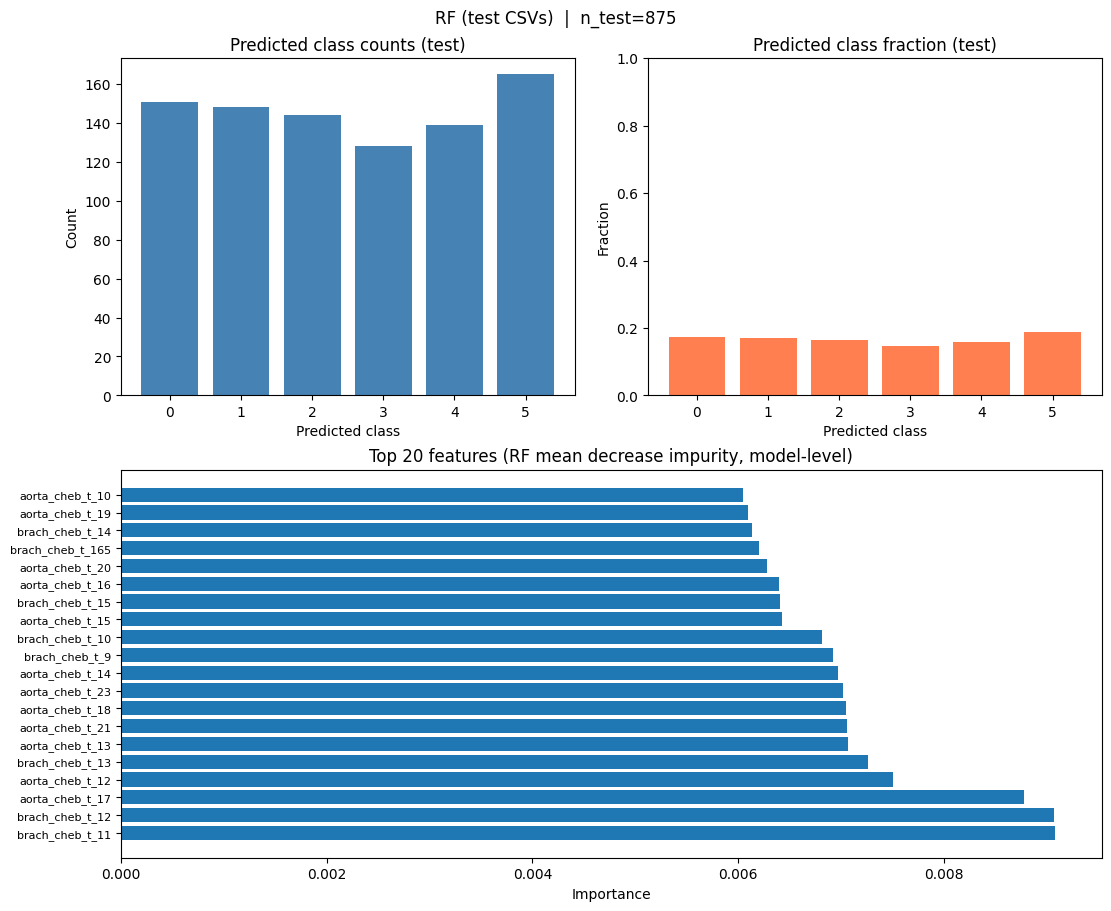

({0: 151, 1: 148, 2: 144, 3: 128, 4: 139, 5: 165}, 'forest_gini')

In [13]:
# Imports are centralized in the first code cell.

# Saved pipeline used for test predictions + feature-importance panel.
EVAL_CLASSIFIER = "rf"  # "rf" | "knn" | "hgb" | "xgb"

_split_seed = globals().get("LAST_TRAIN_RANDOM_STATE")
if _split_seed is None:
    raise RuntimeError(
        "Run a training cell (RF, k-NN, HistGradientBoosting, or XGBoost) first so LAST_TRAIN_RANDOM_STATE is set "
        "(same stratified split as model creation in main())."
    )

_root = NOTEBOOK_DIR.resolve()
if test_csvs is None:
    test_aorta = _root / "datasets/test/aortaP_test_data.csv"
    test_brach = _root / "datasets/test/brachP_test_data.csv"
else:
    test_aorta, test_brach = Path(test_csvs[0]), Path(test_csvs[1])

if not test_aorta.is_file() or not test_brach.is_file():
    raise FileNotFoundError(
        f"Test CSVs not found ({test_aorta}, {test_brach}). "
        "Set TEST_AORTA / TEST_BRACH in Shared settings or add files under datasets/test/."
    )

if training_csvs is None:
    train_aorta = _root / "datasets/train/aortaP_train_data.csv"
    train_brach = _root / "datasets/train/brachP_train_data.csv"
else:
    train_aorta, train_brach = Path(training_csvs[0]), Path(training_csvs[1])

if not train_aorta.is_file() or not train_brach.is_file():
    raise FileNotFoundError(
        f"Training CSVs not found ({train_aorta}, {train_brach}). "
        "Set TRAIN_AORTA / TRAIN_BRACH in Shared settings or add files under datasets/train/."
    )

X_full, y_full = load_train_pair(
    train_aorta,
    train_brach,
    feature_mode=FEATURE_MODE,
    roll_window=ROLL_WINDOW,
    engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_full,
    y_full,
    test_size=VAL_SPLIT,
    random_state=_split_seed,
    stratify=y_full,
)

holdout_preds: list[tuple[str, object]] = []

if "N_ESTIMATORS" in globals():
    _pipe = build_model(
        nan_imputer_cls=NAN_IMPUTER_CLS,
        nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        class_weight=CLASS_WEIGHT,
        n_jobs=N_JOBS,
        random_state=_split_seed,
    )
    _pipe.fit(X_tr, y_tr)
    holdout_preds.append(("RF", _pipe.predict(X_val)))

if "KNN_NEIGHBORS" in globals():
    _pipe = build_knn_pipeline(
        nan_imputer_cls=NAN_IMPUTER_CLS,
        nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
        n_neighbors=KNN_NEIGHBORS,
        weights=KNN_WEIGHTS,
        n_jobs=N_JOBS,
    )
    _pipe.fit(X_tr, y_tr)
    holdout_preds.append(("k-NN", _pipe.predict(X_val)))

if "HGB_MAX_ITER" in globals():
    _pipe = build_hgb_pipeline(
        nan_imputer_cls=NAN_IMPUTER_CLS,
        nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
        learning_rate=HGB_LEARNING_RATE,
        max_iter=HGB_MAX_ITER,
        max_depth=HGB_MAX_DEPTH,
        max_leaf_nodes=HGB_MAX_LEAF_NODES,
        l2_regularization=HGB_L2,
        class_weight=HGB_CLASS_WEIGHT,
        random_state=_split_seed,
        early_stopping=HGB_EARLY_STOPPING,
    )
    _pipe.fit(X_tr, y_tr)
    holdout_preds.append(("HistGradBoost", _pipe.predict(X_val)))

if "XGB_N_ESTIMATORS" in globals() and xgb_available():
    _pipe = build_xgb_pipeline(
        nan_imputer_cls=NAN_IMPUTER_CLS,
        nan_imputer_kwargs=NAN_IMPUTER_KWARGS,
        n_estimators=XGB_N_ESTIMATORS,
        max_depth=XGB_MAX_DEPTH,
        learning_rate=XGB_LEARNING_RATE,
        subsample=XGB_SUBSAMPLE,
        colsample_bytree=XGB_COLSAMPLE_BYTREE,
        reg_lambda=XGB_REG_LAMBDA,
        reg_alpha=XGB_REG_ALPHA,
        min_child_weight=XGB_MIN_CHILD_WEIGHT,
        random_state=_split_seed,
        n_jobs=N_JOBS,
        tree_method=XGB_TREE_METHOD,
    )
    _pipe.fit(X_tr, y_tr)
    holdout_preds.append(("XGBoost", _pipe.predict(X_val)))

if not holdout_preds:
    raise RuntimeError(
        "No holdout models built — run at least one of the RF, k-NN, HistGradientBoosting, or XGBoost cells first."
    )

# Validation confusion matrices: run the final **Side-by-side confusion matrices** notebook cell.

if EVAL_CLASSIFIER == "rf":
    model_path = Path(
        globals().get("SAVE_MODEL_RF", NOTEBOOK_DIR / "models" / "heart_age_rf.joblib")
    )
elif EVAL_CLASSIFIER == "knn":
    model_path = Path(
        globals().get("SAVE_MODEL_KNN", NOTEBOOK_DIR / "models" / "heart_age_knn.joblib")
    )
elif EVAL_CLASSIFIER == "hgb":
    model_path = Path(
        globals().get("SAVE_MODEL_HGB", NOTEBOOK_DIR / "models" / "heart_age_hgb.joblib")
    )
elif EVAL_CLASSIFIER == "xgb":
    model_path = Path(
        globals().get("SAVE_MODEL_XGB", NOTEBOOK_DIR / "models" / "heart_age_xgb.joblib")
    )
else:
    raise ValueError('EVAL_CLASSIFIER must be "rf", "knn", "hgb", or "xgb"')

if not model_path.is_file():
    raise FileNotFoundError(
        f"Missing {model_path}; run the matching training cell above with saving enabled."
    )

pipe = load_fitted_pipeline(model_path)

X_test, _subjects = load_test_pair(
    test_aorta,
    test_brach,
    feature_mode=FEATURE_MODE,
    roll_window=ROLL_WINDOW,
    engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
)

eval_out = visualize_predictions_on_test(
    pipe,
    X_test,
    title_prefix=f"{EVAL_CLASSIFIER.upper()} (test CSVs)",
    top_n_features=20,
    show=True,
)
eval_out["pred_counts"], eval_out["importance_kind"]

### Side-by-side confusion matrices

Run this **after** the ResNet-1D CNN cells (if you want the CNN panel) **and** the **Evaluation on test CSVs** cell (defines `y_val` and `holdout_preds` for tree models). Produces one row of row-normalized matrices: each trained tree/k-NN/HGB/XGB model you ran appears left-to-right, then the CNN (if available). *Note:* tree panels use the stratified validation fold from the evaluation cell; the CNN panel uses the CNN notebook split (`CNN_CV_MODE` holdout or OOF) — labels are comparable in spirit but not necessarily the same rows.


No CNN panel: run the ResNet-1D CNN training cell first (needs y_eval_true, y_eval_pred, CNN_CV_MODE).
=== RF — trees: val holdout (eval cell); CNN: CNN_CV_MODE split — panels may not share the same rows ===
Accuracy: 0.6786  |  MAE: 0.3971  |  QWK: 0.8936
              precision    recall  f1-score   support

           0      0.931     0.931     0.931       116
           1      0.878     0.863     0.871       117
           2      0.556     0.588     0.571       119
           3      0.419     0.379     0.398       116
           4      0.524     0.574     0.548       115
           5      0.768     0.735     0.751       117

    accuracy                          0.679       700
   macro avg      0.679     0.678     0.678       700
weighted avg      0.679     0.679     0.678       700



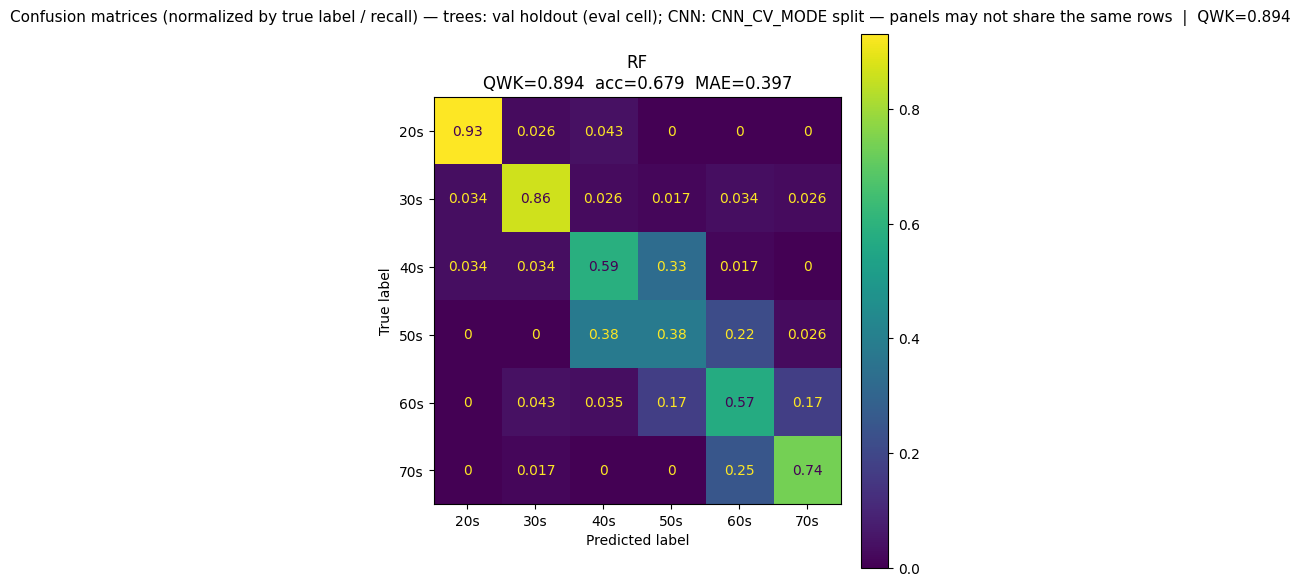

In [14]:
# Row-normalized confusion matrices: tree models (same y_val) + optional CNN in one row.
# Assign the figure so Jupyter doesn't auto-display it *in addition* to plt.show().
panels: list[tuple[str, object, object]] = []

if "holdout_preds" in globals() and "y_val" in globals() and holdout_preds:
    for _name, _yp in holdout_preds:
        panels.append((_name, y_val, _yp))
else:
    print(
        "No tree-model panels: run the Evaluation cell first "
        "(needs y_val, holdout_preds from trained RF / k-NN / HGB / XGB)."
    )

if all(k in globals() for k in ("y_eval_true", "y_eval_pred", "CNN_CV_MODE")):
    panels.append((f"ResNet-1D CNN ({CNN_CV_MODE})", y_eval_true, y_eval_pred))
else:
    print(
        "No CNN panel: run the ResNet-1D CNN training cell first "
        "(needs y_eval_true, y_eval_pred, CNN_CV_MODE)."
    )

if not panels:
    raise RuntimeError(
        "Nothing to plot — run at least the Evaluation cell and/or the CNN training cell, then re-run this cell."
    )

_cm_fig = plot_confusion_matrices_row_panels(
    panels,
    reference_description=(
        "trees: val holdout (eval cell); CNN: CNN_CV_MODE split — panels may not share the same rows"
    ),
    print_reports=True,
    show=True,
)
